# Appendix A – Analysis Notebook

**Predicting EBITDA Growth in UK Mid-Market Private Equity-Owned Companies:
A Machine Learning Approach**

Adrian Igharo (250369782)
MSc Artificial Intelligence with Business Strategy, Aston University
EP4DIS MSc Dissertation, September 2026

---

This notebook reproduces every result, table and figure reported in Chapter 4,
beginning from the raw FAME export.

**Input.** `FAME_export.xlsx`—Companies House financial data retrieved via FAME
(Bureau van Dijk) on 11 September 2026. The FAME search applied five criteria:
active companies not in receivership or dormant; registered in England, Scotland,
Wales or Northern Ireland; turnover of at least £10.2 million in 2022; EBITDA
reported for 2022; and ultimate owner classified as a private equity firm with a
minimum ownership path of 50.01 per cent. This returned 564 companies. Turnover,
EBITDA and employee counts were extracted for 2019 to 2024, together with SIC
code, incorporation date and registered number.

**Design.** Predictors are measured at or before the 2022 baseline; the outcome is
measured over 2022 to 2024. Pre-period trend variables use a 2019 base in the
primary specification, with a 2020 base retained for robustness testing.

**Reproducibility.** All stochastic components use a fixed seed. Model performance
is averaged over twenty cross-validation fold assignments, since a single
five-fold split gives an unstable estimate at this sample size.

## 1  Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
warnings.filterwarnings("ignore", message="IProgress not found")   # cosmetic progress-bar notice from shap
import shap
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)

RANDOM_STATE  = 42
N_SEEDS       = 20      # repeated CV fold assignments
BASELINE_YEAR = 2022    # T
OUTCOME_YEAR  = 2024
PRE_YEAR      = 2019    # primary pre-period base
PRE_YEAR_ALT  = 2020    # Covid-affected base, for robustness

TURNOVER, EBITDA, EMPLOYEE = "Turnover th GBP", "EBITDA th GBP", "Number of employees"
col = lambda base, year: f"{base} {year}"

BLUE, RED, GREY = "#2F5D8C", "#A23B3B", "#B4B4B4"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "figure.dpi": 110,
})

## 2  Load the FAME export

FAME writes `n.a.` for missing values and exports financial fields as text, so
these are coerced to numeric on load. The `Results` sheet carries the data; the
`Search summary` sheet records the search criteria and is retained in the
submitted file for audit purposes.

In [2]:
raw = (pd.read_excel("FAME_export.xlsx", sheet_name="Results", header=0)
         .iloc[:, 1:]                      # drop FAME's row-index column
         .replace("n.a.", np.nan))

for c in raw.columns:
    if any(k in c for k in (TURNOVER, EBITDA, EMPLOYEE)):
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw["Date of incorporation"] = pd.to_datetime(raw["Date of incorporation"], errors="coerce")

print(f"{len(raw)} companies, {raw.shape[1]} columns")
raw[["Company name", col(TURNOVER, 2022), col(EBITDA, 2022),
     col(EMPLOYEE, 2022), "Date of incorporation"]].head()

564 companies, 29 columns


,Company name,Turnover th GBP 2022,EBITDA th GBP 2022,Number of employees 2022,Date of incorporation
0,BELLIS FINCO PLC,24477800.0,908800.0,91538.0,2020-09-03
1,ASDA STORES LIMITED,24461700.0,864100.0,141293.0,1949-02-19
2,ASDA EXPRESS LIMITED,2880401.0,175437.0,7070.0,2001-07-04
3,HALCYON TOPCO LIMITED,1830505.0,22730.0,1721.0,2011-06-16
4,THE VERY GROUP LIMITED,2148300.0,251900.0,3591.0,2003-04-11


## 3  Sample construction

Eight screens are applied. Steps 4 and 5 are requirements of the primary outcome;
the remaining six are discretionary, and each addresses a specific threat to
validity rather than a general preference for cleaner data. Four warrant
explanation here.

**Filing errors.** A turnover movement beyond a factor of twenty in either
direction over two years reflects a restatement, a change of accounting reference
date, or a cessation of trading—not a business outcome. One company reports
turnover of £26.1 million in 2022 and £3,000 in 2024.

**Holding-company stacks.** UK buyouts are executed through layered vehicles, so a
single trading business commonly appears as a Topco, a Midco and a Bidco, each
filing consolidated accounts. Turnover consolidates unchanged up the stack while
EBITDA differs by holding-company costs, so identical baseline turnover reliably
identifies one economic group. A second pass matches on company name stems to
catch stacks whose reported turnover differs marginally. Retaining duplicates
would violate the independence assumption underlying the models.

**Implausible margins.** Companies reporting baseline EBITDA margins above 60
per cent are, on inspection, holding entities whose reported turnover captures
management charges rather than trading income, making the ratio meaningless.

**Secondary outcome (step 8).** Applied inside `build_features`. Four companies
lack 2024 turnover, so margin change is uncomputable, and one records a 54.6
percentage point swing consistent with a restatement. Keeping both outcomes on a
common sample makes them directly comparable.

In [3]:
FILING_ERROR_BOUNDS = (0.05, 20)
TURNOVER_FLOOR_K, TURNOVER_CEILING_K = 10_200, 300_000
MARGIN_CEILING = 0.60

VEHICLE = r"\b(TOPCO|BIDCO|MIDCO|HOLDCO|FINCO|PARENTCO)\b"
STRUCTURAL = (r"\b(TOPCO|BIDCO|MIDCO|HOLDCO|FINCO|PARENTCO|HOLDINGS?|"
              r"ACQUISITIONS?|GROUP|UK|LIMITED|LTD|PLC|LLP)\b")

def _annotate(df):
    df = df.copy()
    df["_complete"] = df[[col(EBITDA, y)
                          for y in range(PRE_YEAR, OUTCOME_YEAR + 1)]].notna().sum(axis=1)
    df["_vehicle"] = df["Company name"].str.upper().str.contains(VEHICLE, regex=True, na=False)
    return df

def dedupe_by_turnover(df):
    """Collapse stacks sharing identical baseline turnover."""
    t = col(TURNOVER, BASELINE_YEAR)
    df = _annotate(df)
    ranked = (df[df[t].notna()]
                .sort_values(["_complete", "_vehicle", "Date of incorporation"],
                             ascending=[False, True, True]))
    keep = ranked.drop_duplicates(t, keep="first").index
    return df.loc[sorted(set(keep) | set(df[df[t].isna()].index))]

def dedupe_by_name_stem(df):
    """Second pass: match on name stem after stripping structural suffixes."""
    df = _annotate(df)
    df["_stem"] = (df["Company name"].str.upper()
                     .str.replace(r"[^A-Z ]", "", regex=True)
                     .str.replace(STRUCTURAL, "", regex=True)
                     .str.split().str[:2].str.join(" ").str.strip())
    long_stem = df[df["_stem"].str.len() > 3]
    kept = (long_stem.sort_values(["_complete", "_vehicle"], ascending=[False, True])
                     .drop_duplicates("_stem", keep="first"))
    return pd.concat([kept, df[df["_stem"].str.len() <= 3]])

def build_sample(df):
    t, e = col(TURNOVER, BASELINE_YEAR), col(EBITDA, BASELINE_YEAR)
    log = [("FAME extract", len(df))]

    ratio = df[col(TURNOVER, OUTCOME_YEAR)] / df[t]
    df = df[~((ratio < FILING_ERROR_BOUNDS[0]) | (ratio > FILING_ERROR_BOUNDS[1])).fillna(False)]
    log.append(("Filing-error screen", len(df)))

    df = dedupe_by_turnover(df)
    log.append(("Deduplicate group stacks (turnover)", len(df)))

    df = df[(df[t] >= TURNOVER_FLOOR_K) & (df[t] <= TURNOVER_CEILING_K)]
    log.append(("Turnover £10.2m-£300m, 2022", len(df)))

    df = df[df[e].notna() & df[col(EBITDA, OUTCOME_YEAR)].notna()]
    log.append(("EBITDA present 2022 and 2024", len(df)))

    df = df[df[e] > 0]                      # growth undefined from non-positive base
    log.append(("Baseline EBITDA positive", len(df)))

    df = dedupe_by_name_stem(df)
    log.append(("Deduplicate group stacks (name stem)", len(df)))

    margin = df[e] / df[t]
    df = df[(margin > 0) & (margin <= MARGIN_CEILING)]
    log.append(("Baseline EBITDA margin 0-60%", len(df)))

    attrition = pd.DataFrame(log, columns=["Screen", "n"])
    attrition["Change"] = attrition["n"].diff().fillna(0).astype(int)
    return df, attrition

sample, attrition = build_sample(raw)
attrition

,Screen,n,Change
0,FAME extract,564,0
1,Filing-error screen,560,-4
2,Deduplicate group stacks (turnover),529,-31
3,"Turnover £10.2m-£300m, 2022",469,-60
4,EBITDA present 2022 and 2024,440,-29
5,Baseline EBITDA positive,390,-50
6,Deduplicate group stacks (name stem),368,-22
7,Baseline EBITDA margin 0-60%,342,-26


## 4  Variables

**Outcome.** Percentage change in EBITDA from 2022 to 2024, winsorised at the
fifth and ninety-fifth percentiles. Percentage growth is unstable when the
denominator is small—one company moving from £28,000 to negative £1.4 million
registers growth of negative 5,140 per cent—but winsorisation retains firms
whose EBITDA turned negative, which a logarithmic transformation would silently
drop. Those are the failure cases most informative about poor performance.

A secondary outcome, change in EBITDA margin in percentage points, is reported
alongside as a robustness check.

**Predictors.** Scale and maturity (log turnover, firm age, log employees);
operational efficiency (revenue per employee, baseline margin); and pre-period
trajectory (revenue CAGR, EBITDA CAGR, margin trend).

In [4]:
FEATURES = ["log_turnover", "firm_age", "log_employees", "rev_per_emp",
            "margin_2022", "rev_cagr_pre", "ebitda_cagr_pre", "margin_trend_pre"]

LABELS = {"log_turnover": "Log turnover", "firm_age": "Firm age",
          "log_employees": "Log employees", "rev_per_emp": "Revenue per employee",
          "margin_2022": "EBITDA margin 2022", "rev_cagr_pre": "Revenue CAGR 2019\u201322",
          "ebitda_cagr_pre": "EBITDA CAGR 2019\u201322",
          "margin_trend_pre": "Margin trend 2019\u201322"}

def build_features(df, pre_year=PRE_YEAR):
    T, O, n = BASELINE_YEAR, OUTCOME_YEAR, BASELINE_YEAR - pre_year
    d = pd.DataFrame(index=df.index)
    d["company"], d["reg_no"] = df["Company name"], df["Registered number"]
    d["sic_div"] = df["Primary UK SIC (2007) code"].astype(str).str.zfill(5).str[:2]

    growth = (df[col(EBITDA, O)] - df[col(EBITDA, T)]) / df[col(EBITDA, T)]
    d["ebitda_growth_raw"] = growth
    d["y_growth"] = growth.clip(*growth.quantile([0.05, 0.95]))

    d["margin_2022"] = df[col(EBITDA, T)] / df[col(TURNOVER, T)]
    d["y_margin_pp"] = (df[col(EBITDA, O)] / df[col(TURNOVER, O)] - d["margin_2022"]) * 100

    d["log_turnover"]  = np.log(df[col(TURNOVER, T)])
    d["firm_age"]      = T - df["Date of incorporation"].dt.year
    d["log_employees"] = np.log(df[col(EMPLOYEE, T)])
    d["rev_per_emp"]   = df[col(TURNOVER, T)] / df[col(EMPLOYEE, T)]

    d["rev_cagr_pre"] = (df[col(TURNOVER, T)] / df[col(TURNOVER, pre_year)]) ** (1 / n) - 1
    d["ebitda_cagr_pre"] = np.where(
        df[col(EBITDA, pre_year)] > 0,
        (df[col(EBITDA, T)] / df[col(EBITDA, pre_year)]) ** (1 / n) - 1, np.nan)
    d["margin_trend_pre"] = (d["margin_2022"]
                             - df[col(EBITDA, pre_year)] / df[col(TURNOVER, pre_year)])

    for c in FEATURES:                       # winsorise against filing anomalies
        d[c] = d[c].clip(*d[c].quantile([0.01, 0.99]))
    # zero headcounts (family group only) would make logs infinite: treat as missing
    d[FEATURES] = d[FEATURES].replace([np.inf, -np.inf], np.nan)
    # Step 8: valid secondary outcome only (uncomputable or implausible margin
    # change excluded), keeping both outcomes on a common sample.
    return d[d["y_margin_pp"].abs() < 50]

d = build_features(sample)
X, y = d[FEATURES], d["y_growth"]

# Record step 8 so the attrition table reconciles with Table 3.1
attrition = pd.concat([attrition, pd.DataFrame([{
    "Screen": "Margin change computable, within 50pp",
    "n": len(d), "Change": len(d) - len(sample)}])], ignore_index=True)
print(attrition.to_string(index=False))
print(f"\nAnalytical sample: n = {len(d)}   retention {len(d)/len(raw)*100:.1f}%")

                               Screen   n  Change
                         FAME extract 564       0
                  Filing-error screen 560      -4
  Deduplicate group stacks (turnover) 529     -31
          Turnover £10.2m-£300m, 2022 469     -60
         EBITDA present 2022 and 2024 440     -29
             Baseline EBITDA positive 390     -50
 Deduplicate group stacks (name stem) 368     -22
         Baseline EBITDA margin 0-60% 342     -26
Margin change computable, within 50pp 337      -5

Analytical sample: n = 337   retention 59.8%


### Table 4.1—Descriptive statistics

In [5]:
s = sample.set_index("Registered number").loc[d["reg_no"]].reset_index()
rows = [("Turnover 2022 (£m)", s[col(TURNOVER, 2022)] / 1000, 1),
        ("EBITDA 2022 (£m)", s[col(EBITDA, 2022)] / 1000, 2),
        ("EBITDA margin 2022 (%)", d["margin_2022"] * 100, 1),
        ("Employees 2022", s[col(EMPLOYEE, 2022)], 0),
        ("Revenue per employee (£000)", d["rev_per_emp"], 0),
        ("Firm age (years)", d["firm_age"], 1),
        ("Revenue CAGR 2019-22 (%)", d["rev_cagr_pre"] * 100, 1),
        ("EBITDA CAGR 2019-22 (%)", d["ebitda_cagr_pre"] * 100, 1),
        ("Margin trend 2019-22 (pp)", d["margin_trend_pre"] * 100, 1),
        ("EBITDA growth 2022-24 (%)", d["ebitda_growth_raw"] * 100, 1),
        ("Margin change 2022-24 (pp)", d["y_margin_pp"], 2)]

pd.DataFrame([{"Variable": lbl, "n": int(x.notna().sum()),
               "Mean": round(x.mean(), r), "SD": round(x.std(), r),
               "P25": round(x.quantile(.25), r), "Median": round(x.median(), r),
               "P75": round(x.quantile(.75), r)} for lbl, x, r in rows]).set_index("Variable")

,n,Mean,SD,P25,Median,P75
Variable,,,,,,
Turnover 2022 (£m),337,50.20,53.90,17.00,28.40,61.40
EBITDA 2022 (£m),337,7.04,11.43,1.39,3.29,7.10
EBITDA margin 2022 (%),337,14.60,12.30,5.70,10.60,20.10
Employees 2022,320,258.00,404.00,68.00,132.00,278.00
Revenue per employee (£000),320,532.00,1355.00,130.00,209.00,445.00
Firm age (years),337,22.80,19.10,10.00,18.00,33.00
Revenue CAGR 2019-22 (%),281,12.10,18.90,1.80,7.80,17.30
EBITDA CAGR 2019-22 (%),263,16.20,31.10,-4.30,11.00,32.30
Margin trend 2019-22 (pp),281,1.50,10.90,-2.10,0.80,5.40


## 5  Models

Four specifications. OLS provides an unregularised linear benchmark; LASSO adds
L1 feature selection, valuable at this sample size; random forest models
non-linear interactions without explicit specification; and XGBoost is included
as the candidate for strongest predictive performance.

Imputation sits inside the pipeline so it is fitted on training folds only,
preventing leakage from validation data.

In [6]:
def make_pipeline(model, scale=False):
    steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scale", StandardScaler()))
    return Pipeline(steps + [("model", model)])

def models():
    return {
        "OLS":   make_pipeline(LinearRegression(), scale=True),
        "LASSO": make_pipeline(LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=5000),
                               scale=True),
        "Random forest": make_pipeline(RandomForestRegressor(
            n_estimators=500, min_samples_leaf=8, random_state=RANDOM_STATE, n_jobs=-1)),
        "XGBoost": make_pipeline(XGBRegressor(
            n_estimators=300, max_depth=2, learning_rate=0.03, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=2, random_state=RANDOM_STATE, n_jobs=-1)),
    }

### Why performance is averaged over twenty fold assignments

A single five-fold split gives an estimate that depends materially on how
observations happen to fall across folds. At this sample size the variation is
large enough to change the conclusion, so every reported figure is a mean over
twenty different fold assignments.

In [7]:
def evaluate(X, y, n_seeds=N_SEEDS):
    # Returns (summary table, per-seed R2 by model). Seeds computed once.
    naive = np.full(len(y), y.mean())
    rows = [{"Model": "Mean predictor",
             "RMSE": np.sqrt(mean_squared_error(y, naive)),
             "MAE": mean_absolute_error(y, naive), "R2 mean": 0.0, "R2 SD": 0.0}]
    per_seed = {}
    for name, model in models().items():
        r2s, rmses, maes = [], [], []
        for seed in range(n_seeds):
            pred = cross_val_predict(model, X, y,
                                     cv=KFold(5, shuffle=True, random_state=seed), n_jobs=1)
            r2s.append(r2_score(y, pred))
            rmses.append(np.sqrt(mean_squared_error(y, pred)))
            maes.append(mean_absolute_error(y, pred))
        per_seed[name] = r2s
        rows.append({"Model": name, "RMSE": np.mean(rmses), "MAE": np.mean(maes),
                     "R2 mean": np.mean(r2s), "R2 SD": np.std(r2s)})
    return pd.DataFrame(rows).set_index("Model").round(3), pd.DataFrame(per_seed)

perf_growth, spread = evaluate(X, y)
perf_growth

,RMSE,MAE,R2 mean,R2 SD
Model,,,,
Mean predictor,1.235,0.861,0.000,0.000
OLS,1.182,0.852,0.083,0.035
LASSO,1.184,0.844,0.080,0.035
Random forest,1.149,0.827,0.134,0.022
XGBoost,1.170,0.839,0.103,0.036


In [8]:
# Seed-level spread, from the same runs summarised above
print("Out-of-sample R2 across", N_SEEDS, "fold assignments\n")
print(spread.agg(["mean", "std", "min", "max"]).round(3).to_string())
print(f"\nRandom forest beats OLS in "
      f"{(spread['Random forest'] > spread['OLS']).sum()}/{N_SEEDS} seeds")

Out-of-sample R2 across 20 fold assignments

        OLS  LASSO  Random forest  XGBoost
mean  0.083  0.080          0.134    0.103
std   0.036  0.036          0.022    0.037
min  -0.062 -0.065          0.073    0.025
max   0.116  0.110          0.164    0.160

Random forest beats OLS in 19/20 seeds


### Table 4.2—Model performance, both outcomes

In [9]:
perf_margin, _ = evaluate(X, d["y_margin_pp"])
pd.concat({"EBITDA growth": perf_growth, "Margin change (pp)": perf_margin}, axis=1)

EBITDA growth                       Margin change (pp)                      
                        RMSE    MAE R2 mean  R2 SD               RMSE    MAE R2 mean  R2 SD
Model                                                                                      
Mean predictor         1.235  0.861   0.000  0.000              9.623  6.422   0.000  0.000
OLS                    1.182  0.852   0.083  0.035              9.117  6.304   0.102  0.024
LASSO                  1.184  0.844   0.080  0.035              9.135  6.236   0.099  0.023
Random forest          1.149  0.827   0.134  0.022              9.321  6.380   0.062  0.026
XGBoost                1.170  0.839   0.103  0.036              9.427  6.480   0.040  0.032

### Table 4.3—OLS with standardised predictors

In [10]:
def ols_standardised(X, y):
    imputed = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                           columns=X.columns, index=X.index)
    z = (imputed - imputed.mean()) / imputed.std()
    fit = sm.OLS(y, sm.add_constant(z)).fit()
    tab = pd.DataFrame({"Coefficient": fit.params.round(3),
                        "SE": fit.bse.round(3), "p": fit.pvalues.round(3)})
    return tab, fit

for outcome, name in [("y_growth", "EBITDA growth"), ("y_margin_pp", "Margin change (pp)")]:
    tab, fit = ols_standardised(X, d[outcome])
    print(f"--- {name} ---")
    print(tab.to_string())
    print(f"R2 = {fit.rsquared:.3f}   adj R2 = {fit.rsquared_adj:.3f}   "
          f"F p = {fit.f_pvalue:.4f}\n")

--- EBITDA growth ---
                  Coefficient     SE      p
const                   0.363  0.063  0.000
log_turnover           -0.146  0.091  0.107
firm_age               -0.177  0.064  0.006
log_employees           0.203  0.109  0.064
rev_per_emp             0.020  0.093  0.833
margin_2022            -0.123  0.066  0.065
rev_cagr_pre            0.244  0.076  0.001
ebitda_cagr_pre        -0.385  0.084  0.000
margin_trend_pre       -0.064  0.077  0.407
R2 = 0.152   adj R2 = 0.131   F p = 0.0000

--- Margin change (pp) ---
                  Coefficient     SE      p
const                  -1.320  0.482  0.006
log_turnover           -0.173  0.695  0.803
firm_age               -0.184  0.488  0.706
log_employees          -0.932  0.837  0.266
rev_per_emp            -1.532  0.712  0.032
margin_2022            -2.311  0.509  0.000
rev_cagr_pre            2.205  0.583  0.000
ebitda_cagr_pre        -1.623  0.640  0.012
margin_trend_pre       -1.111  0.591  0.061
R2 = 0.179   adj R2 = 0.159

## 6  Feature importance

SHAP decomposes each prediction into per-feature contributions, giving
directional interpretation that permutation importance does not. Applied to the
random forest, the best-performing specification.

In [11]:
imputed = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                       columns=X.columns, index=X.index)
forest = RandomForestRegressor(n_estimators=500, min_samples_leaf=8,
                               random_state=RANDOM_STATE, n_jobs=-1).fit(imputed, y)
shap_values = shap.TreeExplainer(forest).shap_values(imputed)

importance = pd.Series(np.abs(shap_values).mean(axis=0),
                       index=X.columns).sort_values(ascending=False)
pd.DataFrame({"Mean |SHAP|": importance.round(4),
              "Share of total": (importance / importance.sum() * 100).round(1)}
             ).rename(index=LABELS)

,Mean |SHAP|,Share of total
EBITDA CAGR 2019–22,0.2346,31.1
Firm age,0.1881,25.0
EBITDA margin 2022,0.1349,17.9
Revenue per employee,0.0527,7.0
Margin trend 2019–22,0.0507,6.7
Revenue CAGR 2019–22,0.0374,5.0
Log employees,0.0318,4.2
Log turnover,0.0236,3.1


## 7  Mean reversion

The dominant pattern in the data. Companies whose EBITDA grew fastest before 2022
grew slowest afterwards, and vice versa.

In [12]:
quartile = pd.qcut(d["ebitda_cagr_pre"], 4,
                   labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
(d.groupby(quartile, observed=True)
   .agg(n=("y_growth", "size"),
        median_growth_pct=("y_growth", lambda x: round(x.median() * 100, 1)),
        median_margin_pp=("y_margin_pp", lambda x: round(x.median(), 2))))

,n,median_growth_pct,median_margin_pp
ebitda_cagr_pre,,,
Q1 (lowest),66,55.5,1.25
Q2,66,4.8,0.40
Q3,65,13.3,-2.31
Q4 (highest),66,-6.3,-1.33


## 8  Robustness: pre-period base year

Trend variables calculated from a 2020 base are contaminated by the pandemic. A
company whose earnings collapsed in 2020 and recovered by 2022 registers as
high-growth when it has merely returned to trend. Recalculating from a 2019 base
establishes which findings survive.

In [13]:
rows = []
for label, year in [("Covid base (2020-22)", PRE_YEAR_ALT),
                    ("Pre-Covid base (2019-22)", PRE_YEAR)]:
    dd = build_features(sample, pre_year=year)
    for f in ["ebitda_cagr_pre", "margin_trend_pre", "rev_cagr_pre", "margin_2022"]:
        pair = dd[[f, "y_margin_pp"]].dropna()
        rho, p = stats.spearmanr(pair[f], pair["y_margin_pp"])
        rows.append({"Specification": label, "Predictor": LABELS[f],
                     "rho": round(rho, 3), "p": round(p, 3)})

pd.DataFrame(rows).pivot(index="Predictor", columns="Specification",
                         values=["rho", "p"])

rho                                             p                         
Specification        Covid base (2020-22) Pre-Covid base (2019-22) Covid base (2020-22) Pre-Covid base (2019-22)
Predictor                                                                                                       
EBITDA CAGR 2019–22                -0.261                   -0.258                0.000                    0.000
EBITDA margin 2022                 -0.212                   -0.212                0.000                    0.000
Margin trend 2019–22               -0.274                   -0.282                0.000                    0.000
Revenue CAGR 2019–22               -0.140                    0.012                0.016                    0.844

In [14]:
# Does model performance depend on the pre-period base?
d_alt = build_features(sample, pre_year=PRE_YEAR_ALT)
perf_alt, _ = evaluate(d_alt[FEATURES], d_alt["y_growth"])
pd.concat({"Pre-Covid base (2019)": perf_growth["R2 mean"],
           "Covid base (2020)": perf_alt["R2 mean"]}, axis=1).round(3)

,Pre-Covid base (2019),Covid base (2020)
Model,,
Mean predictor,0.000,0.000
OLS,0.083,0.012
LASSO,0.080,0.024
Random forest,0.134,0.133
XGBoost,0.103,0.118


## 9  Robustness of model performance

Section 8 tests the signal; this section tests the models. Repeated five-fold
assignments reuse the same 337 companies, so their results are not independent
and a conventional t-test overstates confidence. The corrected resampled t-test
of Nadeau and Bengio (2003) inflates the variance by the test/train ratio to
account for this. The remaining checks tune the hyperparameters by nested
cross-validation, shorten the outcome to one year, and add sector indicators.

In [15]:
def fold_mse_diffs(model_a, model_b, X, y):
    # MSE(model_a) - MSE(model_b) per fold; model_a=None uses the training-fold mean
    diffs = []
    for seed in range(N_SEEDS):
        for tr, te in KFold(5, shuffle=True, random_state=seed).split(X):
            yb = model_b().fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
            ya = (np.full(len(te), y.iloc[tr].mean()) if model_a is None
                  else model_a().fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te]))
            diffs.append(mean_squared_error(y.iloc[te], ya) - mean_squared_error(y.iloc[te], yb))
    return np.array(diffs)

def corrected_t(diffs, k=5, ratio=0.25):
    m, v = diffs.mean(), diffs.var(ddof=1)
    t = m / np.sqrt((1 / (k * N_SEEDS) + ratio) * v)
    return t, 2 * stats.t.sf(abs(t), k * N_SEEDS - 1), stats.ttest_1samp(diffs, 0).pvalue

OLSf = lambda: make_pipeline(LinearRegression(), scale=True)
RFf  = lambda: make_pipeline(RandomForestRegressor(n_estimators=500, min_samples_leaf=8,
                                                   random_state=RANDOM_STATE, n_jobs=-1))
for label, a, b in [("RF vs mean", None, RFf), ("OLS vs mean", None, OLSf), ("RF vs OLS", OLSf, RFf)]:
    t, p, p_conv = corrected_t(fold_mse_diffs(a, b, X, y))
    print(f"{label:12s} corrected t = {t:5.2f}, p = {p:.3f}   (conventional p = {p_conv:.5f})")

RF vs mean   corrected t =  2.09, p = 0.039   (conventional p = 0.00000)


OLS vs mean  corrected t =  1.53, p = 0.129   (conventional p = 0.00000)


RF vs OLS    corrected t =  0.82, p = 0.416   (conventional p = 0.00007)


In [16]:
def mean_r2(factory, X, y):
    return np.mean([r2_score(y, cross_val_predict(factory(), X, y,
                    cv=KFold(5, shuffle=True, random_state=s), n_jobs=1)) for s in range(N_SEEDS)])

def nested(estimator, grid, X, y):
    r2s, chosen = [], []
    for seed in range(N_SEEDS):
        pred = np.empty(len(y))
        for tr, te in KFold(5, shuffle=True, random_state=seed).split(X):
            gs = GridSearchCV(estimator, grid, scoring="neg_mean_squared_error",
                              cv=KFold(3, shuffle=True, random_state=seed), n_jobs=-1)
            gs.fit(X.iloc[tr], y.iloc[tr]); pred[te] = gs.predict(X.iloc[te])
            chosen.append(str(sorted(gs.best_params_.items())))
        r2s.append(r2_score(y, pred))
    return np.mean(r2s), pd.Series(chosen).value_counts().head(2)

tuned_rf = nested(make_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
                  {"model__min_samples_leaf": [4, 8, 16], "model__max_features": ["sqrt", 1.0]}, X, y)
tuned_xgb = nested(make_pipeline(XGBRegressor(n_estimators=300, subsample=0.8, colsample_bytree=0.8,
                                              reg_lambda=2, random_state=RANDOM_STATE, n_jobs=1)),
                   {"model__max_depth": [2, 3, 4], "model__learning_rate": [0.03, 0.1]}, X, y)

s1 = sample.set_index("Registered number").loc[d["reg_no"]].reset_index()
g1 = (s1[col(EBITDA, 2023)] - s1[col(EBITDA, 2022)]) / s1[col(EBITDA, 2022)]
keep = g1.notna().values
y1 = g1[keep].clip(*g1[keep].quantile([0.05, 0.95])).reset_index(drop=True)
X1 = X[keep].reset_index(drop=True)
rho1 = stats.spearmanr(X1["ebitda_cagr_pre"], y1, nan_policy="omit")

vc = d["sic_div"].value_counts()
grp = np.where(d["sic_div"].isin(vc[vc >= 10].index), d["sic_div"], "other")
Xs = pd.concat([X, pd.get_dummies(pd.Series(grp, index=d.index), prefix="sic",
                                  drop_first=True).astype(float)], axis=1)

table_4_5 = pd.DataFrame({
    "Random forest": [perf_growth.loc["Random forest", "R2 mean"], perf_alt.loc["Random forest", "R2 mean"],
                      tuned_rf[0], mean_r2(RFf, Xs, y), mean_r2(RFf, X1, y1)],
    "OLS": [perf_growth.loc["OLS", "R2 mean"], perf_alt.loc["OLS", "R2 mean"],
            np.nan, mean_r2(OLSf, Xs, y), mean_r2(OLSf, X1, y1)]},
    index=["Primary (2019 base, two-year horizon)", "2020 base", "Tuned hyperparameters",
           "With sector indicators", "One-year horizon"]).round(3)
print(f"Tuned XGBoost R2 = {tuned_xgb[0]:.3f}")
print(f"One-year horizon: Spearman rho = {rho1.statistic:.3f} (p = {rho1.pvalue:.4f})")
print("Most-chosen random forest settings:"); print(tuned_rf[1].to_string())
table_4_5

Tuned XGBoost R2 = 0.094
One-year horizon: Spearman rho = -0.212 (p = 0.0005)
Most-chosen random forest settings:
[('model__max_features', 1.0), ('model__min_samples_leaf', 8)]       37
[('model__max_features', 'sqrt'), ('model__min_samples_leaf', 8)]    23


,Random forest,OLS
"Primary (2019 base, two-year horizon)",0.134,0.083
2020 base,0.133,0.012
Tuned hyperparameters,0.113,NaN
With sector indicators,0.137,0.044
One-year horizon,-0.034,0.015


## 10  Asymmetric reversion

Fama and French (2000) find that profitability reverts faster from below its
mean. A piecewise regression lets the slope on pre-period EBITDA growth differ
either side of its median, with the other predictors as controls.

In [17]:
def piecewise_slopes(df, var, outcome):
    t = df[df[var].notna()].copy(); k = t[var].median()
    t["below"] = np.minimum(t[var] - k, 0); t["above"] = np.maximum(t[var] - k, 0)
    ctrl = [f for f in FEATURES if f != var]
    t[ctrl] = SimpleImputer(strategy="median").fit_transform(t[ctrl])
    m = sm.OLS(t[outcome], sm.add_constant(t[["below", "above"] + ctrl])).fit(cov_type="HC1")
    return m.params["below"], m.params["above"], m.pvalues["above"], m.t_test("below - above = 0").pvalue

b, a, pa, pdiff = piecewise_slopes(d, "ebitda_cagr_pre", "y_growth")
print(f"EBITDA growth: below median {b:.2f}, above {a:.2f} (p = {pa:.3f}), difference p = {pdiff:.5f}")
print(f"Margin level: difference p = {piecewise_slopes(d, 'margin_2022', 'y_margin_pp')[3]:.2f}")
c = d["ebitda_cagr_pre"].dropna()
print(f"Companies with EBITDA CAGR below -10 per cent: {(c < -0.10).sum()} of {len(c)}")

EBITDA growth: below median -4.50, above -0.68 (p = 0.019), difference p = 0.00008
Margin level: difference p = 0.80
Companies with EBITDA CAGR below -10 per cent: 45 of 263


## 11  Private equity and family ownership

The comparison group uses the same FAME search with family ownership in place
of private equity. Companies appearing in both extracts are removed, the same
eight screens are applied, and differences are tested in a pooled regression
with the outcome winsorised across both groups.

In [18]:
fam_raw = (pd.read_excel("FAME_export_family.xlsx", sheet_name="Results", header=0)
             .iloc[:, 1:].replace("n.a.", np.nan))
for c in fam_raw.columns:
    if any(k in c for k in (TURNOVER, EBITDA, EMPLOYEE)):
        fam_raw[c] = pd.to_numeric(fam_raw[c], errors="coerce")
fam_raw["Date of incorporation"] = pd.to_datetime(fam_raw["Date of incorporation"], errors="coerce")
overlap = set(raw["Registered number"].astype(str)) & set(fam_raw["Registered number"].astype(str))
fam_raw = fam_raw[~fam_raw["Registered number"].astype(str).isin(overlap)].reset_index(drop=True)
fam_sample, fam_attrition = build_sample(fam_raw)
fam = build_features(fam_sample)
print(f"Family extract {len(fam_raw) + len(overlap)}, overlap removed {len(overlap)}, final n = {len(fam)}")
print(f"Median EBITDA growth: PE {d['y_growth'].median()*100:.1f}%, family {fam['y_growth'].median()*100:.1f}%")
print(f"Mean margin change: PE {d['y_margin_pp'].mean():.2f}, family {fam['y_margin_pp'].mean():.2f}")
print(f"Mann-Whitney p: growth {stats.mannwhitneyu(d['y_growth'], fam['y_growth']).pvalue:.2g}, "
      f"margin {stats.mannwhitneyu(d['y_margin_pp'], fam['y_margin_pp']).pvalue:.3f}")

Family extract 9542, overlap removed 14, final n = 6448
Median EBITDA growth: PE 16.6%, family -10.2%
Mean margin change: PE -1.32, family -2.09
Mann-Whitney p: growth 1.2e-06, margin 0.002


In [19]:
pool = pd.concat([d.assign(pe=1.0), fam.assign(pe=0.0)], ignore_index=True)
g = pool["ebitda_growth_raw"]; pool["y_joint"] = g.clip(*g.quantile([0.05, 0.95]))
Z = pool[FEATURES].copy(); Z[:] = SimpleImputer(strategy="median").fit_transform(Z)
Z = (Z - Z.mean()) / Z.std()
Z["pe"] = pool["pe"]
Z["pe_x_ebitda_cagr"] = Z["pe"] * Z["ebitda_cagr_pre"]
Z["pe_x_rev_cagr"] = Z["pe"] * Z["rev_cagr_pre"]
pooled = sm.OLS(pool["y_joint"], sm.add_constant(Z)).fit(cov_type="HC1")
print(pooled.summary2().tables[1].loc[["pe", "pe_x_ebitda_cagr", "pe_x_rev_cagr"], ["Coef.", "P>|z|"]].round(4))
for name, grp in [("PE", pool[pool.pe == 1]), ("family", pool[pool.pe == 0])]:
    r = stats.spearmanr(grp["ebitda_cagr_pre"], grp["y_joint"], nan_policy="omit").statistic
    print(f"Spearman reversion {name}: {r:.3f}")
print(f"Family asymmetry difference p = {piecewise_slopes(fam, 'ebitda_cagr_pre', 'y_growth')[3]:.2g}")

                   Coef.   P>|z|
pe                0.1904  0.0006
pe_x_ebitda_cagr -0.1902  0.0145
pe_x_rev_cagr     0.1331  0.0047
Spearman reversion PE: -0.279
Spearman reversion family: -0.247
Family asymmetry difference p = 8.2e-22


In [20]:
RFm  = lambda: make_pipeline(RandomForestRegressor(n_estimators=500, min_samples_leaf=8,
                                                   random_state=RANDOM_STATE, n_jobs=-1))
OLSm = lambda: make_pipeline(LinearRegression(), scale=True)
rng = np.random.default_rng(RANDOM_STATE); rf_fam, ols_fam = [], []
for draw in range(N_SEEDS):
    sub = fam.sample(n=len(d), random_state=int(rng.integers(1e9))).reset_index(drop=True)
    cv = KFold(5, shuffle=True, random_state=draw)
    rf_fam.append(r2_score(sub["y_growth"], cross_val_predict(RFm(), sub[FEATURES], sub["y_growth"], cv=cv)))
    ols_fam.append(r2_score(sub["y_growth"], cross_val_predict(OLSm(), sub[FEATURES], sub["y_growth"], cv=cv)))
print(f"Size-matched family samples: RF {np.mean(rf_fam):.3f}, OLS {np.mean(ols_fam):.3f}; "
      f"draws matching the PE random forest: {sum(r >= 0.134 for r in rf_fam)} of {N_SEEDS}")

Size-matched family samples: RF 0.039, OLS 0.021; draws matching the PE random forest: 1 of 20


## 12  Screening value

Companies are sorted into quintiles on their out-of-sample predictions,
averaged over the twenty fold assignments, and realised growth is compared.

In [21]:
for name, f in [("Random forest", RFm), ("OLS", OLSm)]:
    preds = np.mean([cross_val_predict(f(), X, y, cv=KFold(5, shuffle=True, random_state=s))
                     for s in range(N_SEEDS)], axis=0)
    q = pd.qcut(preds, 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    med = (pd.Series(y.values).groupby(q, observed=True).median() * 100).round(1)
    print(f"{name:13s} {med.to_dict()}  rank correlation = {stats.spearmanr(preds, y).statistic:.3f}")

Random forest {'Q1': 2.4, 'Q2': 4.0, 'Q3': 10.9, 'Q4': 15.3, 'Q5': 68.1}  rank correlation = 0.236


OLS           {'Q1': -6.3, 'Q2': 10.5, 'Q3': 8.9, 'Q4': 24.8, 'Q5': 67.4}  rank correlation = 0.284


## 13  Figures

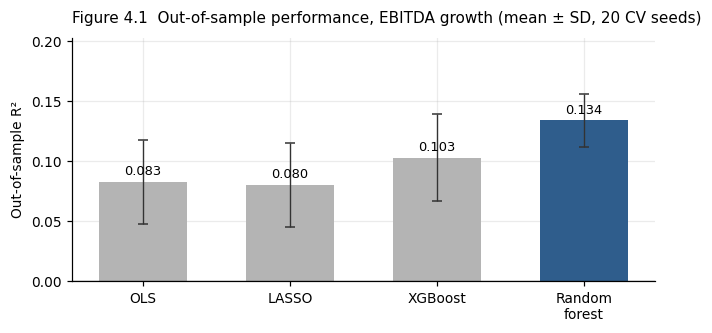

In [22]:
# Figure 4.1 - out-of-sample performance
order = ["OLS", "LASSO", "XGBoost", "Random forest"]
p = perf_growth.loc[order]
fig, ax = plt.subplots(figsize=(6.2, 3.1))
bars = ax.bar([m.replace(" ", "\n") for m in order], p["R2 mean"],
              color=[BLUE if m == "Random forest" else GREY for m in order], width=0.6)
ax.errorbar(range(len(order)), p["R2 mean"], yerr=p["R2 SD"],
            fmt="none", ecolor="#333", capsize=3, lw=0.9)
for bar, v in zip(bars, p["R2 mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.006, f"{v:.3f}", ha="center", fontsize=8.5)
ax.axhline(0, color="#333", lw=0.8)
ax.set_ylabel("Out-of-sample R\u00b2")
ax.set_ylim(0, (p["R2 mean"] + p["R2 SD"]).max() * 1.3)
ax.set_title("Figure 4.1  Out-of-sample performance, EBITDA growth "
             "(mean \u00b1 SD, 20 CV seeds)", loc="left", fontsize=10, pad=10)
plt.tight_layout(); plt.savefig("fig4_1.png", bbox_inches="tight", dpi=200); plt.show()

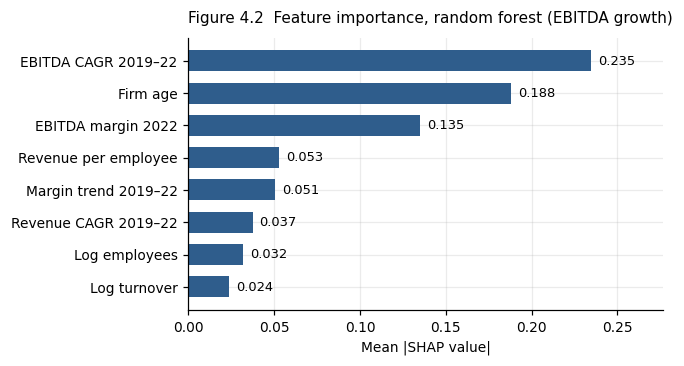

In [23]:
# Figure 4.2 - SHAP importance
ordered = importance.sort_values()
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.barh([LABELS[i] for i in ordered.index], ordered.values, color=BLUE, height=0.65)
for i, v in enumerate(ordered.values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8.5)
ax.set_xlabel("Mean |SHAP value|"); ax.set_xlim(0, ordered.max() * 1.18)
ax.set_title("Figure 4.2  Feature importance, random forest (EBITDA growth)",
             loc="left", fontsize=10, pad=10)
plt.tight_layout(); plt.savefig("fig4_2.png", bbox_inches="tight", dpi=200); plt.show()

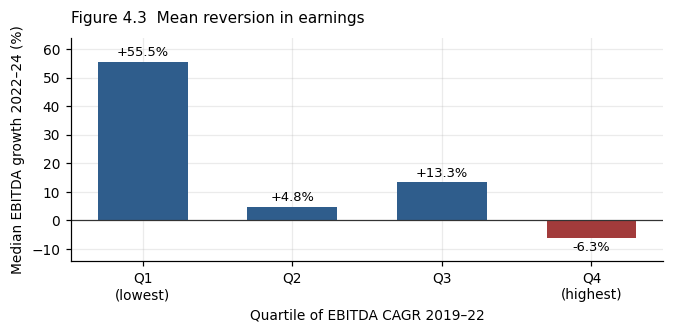

In [24]:
# Figure 4.3 - mean reversion
med = d.groupby(quartile, observed=True)["y_growth"].median() * 100
fig, ax = plt.subplots(figsize=(6.2, 3.1))
bars = ax.bar([str(i).replace(" (", "\n(") for i in med.index], med.values,
              color=[BLUE if v > 0 else RED for v in med.values], width=0.6)
ax.axhline(0, color="#333", lw=0.8)
for bar, v in zip(bars, med.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + (2 if v > 0 else -4.5),
            f"{v:+.1f}%", ha="center", fontsize=8.5)
ax.set_ylabel("Median EBITDA growth 2022\u201324 (%)")
ax.set_xlabel("Quartile of EBITDA CAGR 2019\u201322")
ax.set_ylim(med.min() - 8, med.max() * 1.15)
ax.set_title("Figure 4.3  Mean reversion in earnings", loc="left", fontsize=10, pad=10)
plt.tight_layout(); plt.savefig("fig4_3.png", bbox_inches="tight", dpi=200); plt.show()

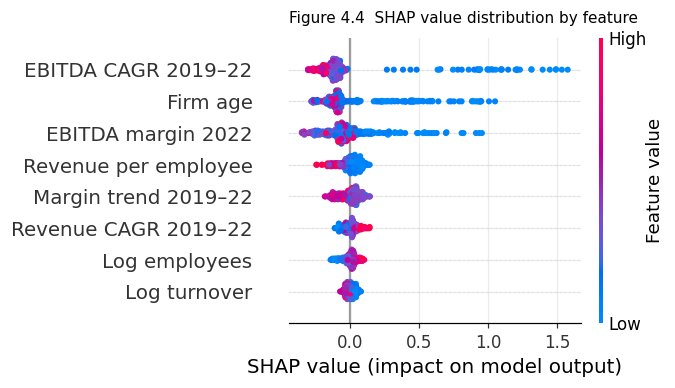

In [25]:
# Figure 4.4 - SHAP beeswarm, showing direction as well as magnitude
plt.figure(figsize=(6.2, 3.6))
shap.summary_plot(shap_values, imputed,
                  feature_names=[LABELS[f] for f in imputed.columns],
                  show=False, plot_size=None, max_display=len(imputed.columns))
plt.title("Figure 4.4  SHAP value distribution by feature", loc="left", fontsize=10, pad=10)
plt.tight_layout(); plt.savefig("fig4_4.png", bbox_inches="tight", dpi=200); plt.show()

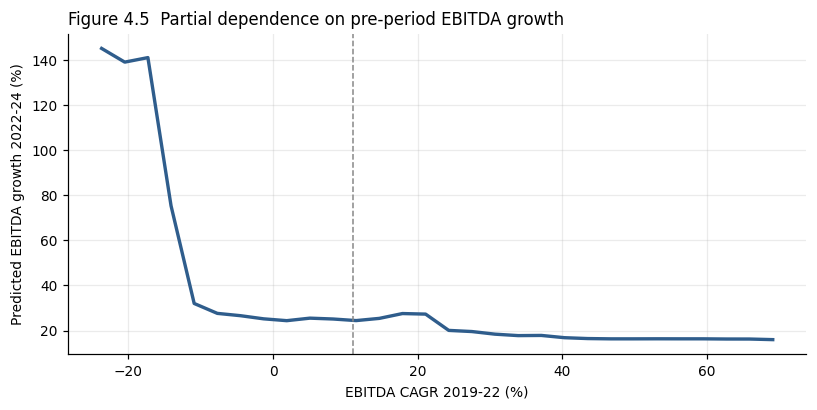

In [26]:
from sklearn.inspection import partial_dependence
Xi = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=FEATURES)
rf_pd = RandomForestRegressor(n_estimators=500, min_samples_leaf=8, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(Xi, y)
pdp = partial_dependence(rf_pd, Xi, ["ebitda_cagr_pre"], grid_resolution=30)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(pdp["grid_values"][0] * 100, pdp["average"][0] * 100, color="#2F5D8C", linewidth=2.2)
ax.axvline(X["ebitda_cagr_pre"].median() * 100, color="#888888", linestyle="--", linewidth=1)
ax.set_xlabel("EBITDA CAGR 2019-22 (%)"); ax.set_ylabel("Predicted EBITDA growth 2022-24 (%)")
ax.set_title("Figure 4.5  Partial dependence on pre-period EBITDA growth", loc="left")
plt.tight_layout(); plt.savefig("fig4_5.png", bbox_inches="tight", dpi=200); plt.show()

## 14  Export

The cleaned analytical dataset is written for reference. Chapter 4 reports every
result above.

In [27]:
d.to_csv("analytical_sample.csv", index=False)
print(f"analytical_sample.csv written: {len(d)} companies, {d.shape[1]} columns")

analytical_sample.csv written: 337 companies, 14 columns
